# Homework I: Investigation of SVM

In [14]:
# Import statement
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

## Dataset

In [15]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(df.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

## Data Info

In [16]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

(569, 30)

# Dataset characteristics:
 - Total samples: 569
 - Number of features: 30 (all numeric)
 - Target classes:
       0 -> malignant
       1 -> benign

In this investigation, benign (label = 1) is treated as the
positive class.

In [17]:
print(df.shape)
print(data.target_names)

(569, 30)
['malignant' 'benign']


In this homework, benign (label=1) is treated as the positive class.

In [18]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Check for missing values

In [19]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In this dataset, there are no missing values and all features contain complete values.

## Data Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df, y,train_size=0.8,random_state=42, stratify=y)

The dataset is divided into:
- 80% Training data
- 20% Testing data

Stratified sampling is used to preserve the proportion of
malignant and benign cases in both sets.
The testing set is used only for final evaluation.

## Feature selection

In [21]:
selector = SelectKBest(score_func=f_classif, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

print("Selected feature indices:", selector.get_support(indices=True))

Selected feature indices: [ 2  7 20 22 27]


To reduce dimensionality and prevent overfitting, we select the top 5 most significant features using univariate feature selection.
Benefits:
- Reduces model complexity
- Improves generalization
- Reduces computational cost

Only the training data is used to fit the selector to avoid data leakage.

## Standardize the data

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

SVM is sensitive to feature scale because it relies on distance calculations.
Therefore, features are standardized to have:
- Mean = 0
- Standard deviation = 1

The scaler is fitted only on training data and then applied to both training and testing sets.

## SVM Models and Evaluation

We evaluate multiple SVM kernels:

1. Linear Kernel
2. Polynomial Kernel (degree 2, 3, 4)
3. Gaussian (RBF) Kernel with different gamma values
4. Sigmoid Kernel

We also investigate the effect of regularization parameter C for the linear kernel.

Each kernel produces a different decision boundary:
- Linear: Straight hyperplane
- Polynomial: Curved boundary
- RBF: Highly flexible nonlinear boundary
- Sigmoid: Similar to neural network activation

In [23]:
kernels = {
    "Linear (C = 0.1)": SVC(kernel="linear", random_state=42, C = 0.1), ## Linear Kernel C = 0.1
    "Linear (C = 1)": SVC(kernel="linear", random_state=42, C = 1), ## Linear Kernel C = 1
    "Linear (C = 10)": SVC(kernel="linear", random_state=42, C = 10), ## Linear Kernel C = 10
    "Poly (degree=2)": SVC(kernel="poly", degree=2, random_state=42), ## Polynomial Kernel degree = 2
    "Poly (degree=3)": SVC(kernel="poly", degree=3, random_state=42), ## Polynomial Kernel degree = 3
    "Poly (degree=4)": SVC(kernel="poly", degree=4, random_state=42), ## Polynomial Kernel degree = 4
    "Gaussian (RBF,Gamma - 0.01)": SVC(kernel="rbf", gamma=0.01, random_state=42), ## Gaussian Kernel Gamma = 0.01
    "Gaussian (RBF),Gamma - 0.1": SVC(kernel="rbf", gamma=0.1, random_state=42), ## Gaussian Kernel Gamma = 0.1
    "Gaussian (RBF),Gamma - 1.0": SVC(kernel="rbf", gamma=1, random_state=42), ## Gaussian Kernel Gamma = 1
    "Sigmoid_g0.01_c0": SVC(kernel="sigmoid", random_state=42, gamma=0.01, coef0=0), ## Sigmoid Kernel Gamma = 0.01 Coef = 0
    "Sigmoid_g0.1_c1": SVC(kernel="sigmoid", random_state=42, gamma=0.1, coef0=1) ## Sigmoid Kernel Gamma = 0.1 Coef = 1
}

results = []

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Manual metric calculations
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    results.append({
        "Kernel": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"\nKernel: {name}")
    print("Confusion Matrix:\n", cm)
    print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")



Kernel: Linear (C = 0.1)
Confusion Matrix:
 [[40  2]
 [ 5 67]]
TP = 67, TN = 40, FP = 2, FN = 5
Accuracy  : 0.9386
Precision : 0.9710
Recall    : 0.9306
F1 Score  : 0.9504

Kernel: Linear (C = 1)
Confusion Matrix:
 [[40  2]
 [ 4 68]]
TP = 68, TN = 40, FP = 2, FN = 4
Accuracy  : 0.9474
Precision : 0.9714
Recall    : 0.9444
F1 Score  : 0.9577

Kernel: Linear (C = 10)
Confusion Matrix:
 [[40  2]
 [ 2 70]]
TP = 70, TN = 40, FP = 2, FN = 2
Accuracy  : 0.9649
Precision : 0.9722
Recall    : 0.9722
F1 Score  : 0.9722

Kernel: Poly (degree=2)
Confusion Matrix:
 [[18 24]
 [ 0 72]]
TP = 72, TN = 18, FP = 24, FN = 0
Accuracy  : 0.7895
Precision : 0.7500
Recall    : 1.0000
F1 Score  : 0.8571

Kernel: Poly (degree=3)
Confusion Matrix:
 [[32 10]
 [ 0 72]]
TP = 72, TN = 32, FP = 10, FN = 0
Accuracy  : 0.9123
Precision : 0.8780
Recall    : 1.0000
F1 Score  : 0.9351

Kernel: Poly (degree=4)
Confusion Matrix:
 [[18 24]
 [ 0 72]]
TP = 72, TN = 18, FP = 24, FN = 0
Accuracy  : 0.7895
Precision : 0.7500
Rec

## Result Analysis

In [24]:
results_df = pd.DataFrame(results)
print(results_df)

                         Kernel  Accuracy  Precision    Recall  F1 Score
0              Linear (C = 0.1)  0.938596   0.971014  0.930556  0.950355
1                Linear (C = 1)  0.947368   0.971429  0.944444  0.957746
2               Linear (C = 10)  0.964912   0.972222  0.972222  0.972222
3               Poly (degree=2)  0.789474   0.750000  1.000000  0.857143
4               Poly (degree=3)  0.912281   0.878049  1.000000  0.935065
5               Poly (degree=4)  0.789474   0.750000  1.000000  0.857143
6   Gaussian (RBF,Gamma - 0.01)  0.929825   0.932432  0.958333  0.945205
7    Gaussian (RBF),Gamma - 0.1  0.938596   0.971014  0.930556  0.950355
8    Gaussian (RBF),Gamma - 1.0  0.964912   0.972222  0.972222  0.972222
9              Sigmoid_g0.01_c0  0.938596   0.933333  0.972222  0.952381
10              Sigmoid_g0.1_c1  0.929825   0.970588  0.916667  0.942857


The SVM kernel comparison shows that Linear (C = 10) and RBF (Gamma = 1.0) achieved the best overall performance, with the highest accuracy (96.49%) and F1 score (0.9722), indicating an excellent balance between precision and recall. Increasing the regularization parameter C improved linear kernel performance, suggesting the dataset is close to linearly separable when properly tuned. 

The rest of the RBF kernels also performed very strongly, especially with higher gamma values, demonstrating its ability to model nonlinear decision boundaries effectively. Polynomial kernels of degree 2 and 4 showed lower accuracy and precision despite achieving perfect recall, indicating overfitting and excessive false positives, while the sigmoid kernel produced stable but slightly inferior results compared to the top models. 

Overall, the results suggest that either a well-regularized linear SVM or an appropriately tuned RBF kernel is most suitable for this classification problem.

## Plots

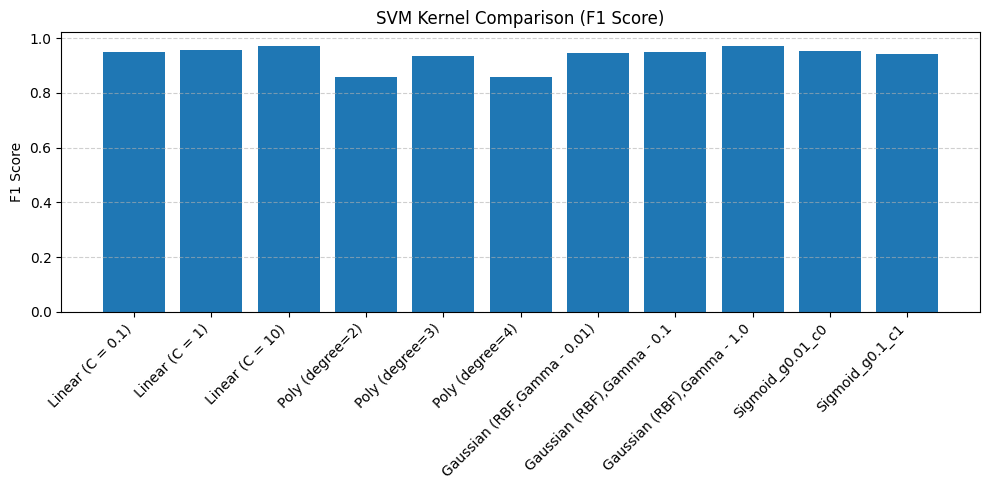

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Kernel"], results_df["F1 Score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("SVM Kernel Comparison (F1 Score)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


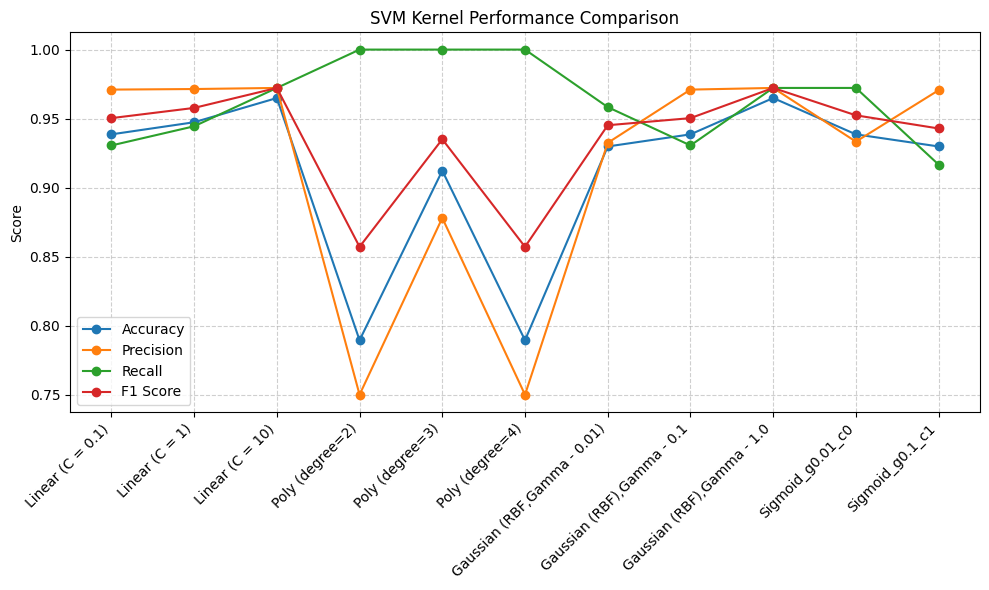

In [26]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(
        results_df["Kernel"],
        results_df[metric],
        marker="o",
        label=metric
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("SVM Kernel Performance Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The plots clearly show that Linear (C = 10) and RBF (Gamma = 1.0) achieve the highest and most balanced performance across all metrics, particularly in F1 score. This confirms that either a well-regularized linear model or a properly tuned RBF kernel is most suitable for this classification task.